# Louisville Crime Analysis 2004 - 2025

In [10]:
## import packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3


## Create dotenv for Loading and Protecting Census API Key

In [8]:
!pip install python-dotenv

import os

from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
key = os.getenv("CENSUS_API_KEY")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Combine Crime Reports, Create Dataframes for Each, and Add a 'Year' Column
- Goal of this prep work is to get a combined and cleaned dataframe that includes all years of crime with renaming of headers.

In [11]:
import glob

def combine_crime_csvs(data_path):
    """
    Combines all yearly Louisville crime CSV files into one DataFrame.
    Adds a 'year' column to each file based on the filename.
    
    Parameters:
        data_path (str): Path to the folder containing Crime_Data_*.csv files
    
    Returns:
        crime_data_by_year (dict): Dictionary of DataFrames keyed by year
        combined (DataFrame): Single combined DataFrame of all years
    """
    
    # Load all CSV files and sort in order
    all_crime_files = sorted(glob.glob(f'{data_path}/Crime_Data_*.csv'))
    
    if not all_crime_files:
        raise FileNotFoundError(f"No Crime_Data_*.csv files found in {data_path}")
    
    # Loop through each file, split filename to get year, add year column
    crime_data_by_year = {}
    for file in all_crime_files:
        year = int(file.split('_')[-1].replace('.csv', ''))
        crime_data_by_year[year] = pd.read_csv(file, low_memory=False)
        crime_data_by_year[year]['year'] = year
        print(f"  Loaded {year}: {len(crime_data_by_year[year]):,} rows")

    # Combine all years into one DataFrame
    combined = pd.concat(crime_data_by_year.values(), ignore_index=True)
    print(f"\nTotal combined rows: {len(combined):,}")
    
    return crime_data_by_year, combined


# --- Call the function ---
crime_data_by_year, df_all_years = combine_crime_csvs('../initial_lou_crime_data')

# --- Assign individual year DataFrames ---
# These are used downstream in the notebook for header standardization
df_2004 = crime_data_by_year[2004]
df_2005 = crime_data_by_year[2005]
df_2006 = crime_data_by_year[2006]
df_2007 = crime_data_by_year[2007]
df_2008 = crime_data_by_year[2008]
df_2009 = crime_data_by_year[2009]
df_2010 = crime_data_by_year[2010]
df_2011 = crime_data_by_year[2011]
df_2012 = crime_data_by_year[2012]
df_2013 = crime_data_by_year[2013]
df_2014 = crime_data_by_year[2014]
df_2015 = crime_data_by_year[2015]
df_2016 = crime_data_by_year[2016]
df_2017 = crime_data_by_year[2017]
df_2018 = crime_data_by_year[2018]
df_2019 = crime_data_by_year[2019]
df_2020 = crime_data_by_year[2020]
df_2021 = crime_data_by_year[2021]
df_2022 = crime_data_by_year[2022]
df_2023 = crime_data_by_year[2023]
df_2024 = crime_data_by_year[2024]
df_2025 = crime_data_by_year[2025]

  Loaded 2004: 70,696 rows
  Loaded 2005: 77,347 rows
  Loaded 2006: 83,851 rows
  Loaded 2007: 90,767 rows
  Loaded 2008: 86,481 rows
  Loaded 2009: 78,380 rows
  Loaded 2010: 82,871 rows
  Loaded 2011: 86,013 rows
  Loaded 2012: 81,406 rows
  Loaded 2013: 77,127 rows
  Loaded 2014: 77,466 rows
  Loaded 2015: 79,839 rows
  Loaded 2016: 84,535 rows
  Loaded 2017: 82,113 rows
  Loaded 2018: 80,000 rows
  Loaded 2019: 73,420 rows
  Loaded 2020: 70,233 rows
  Loaded 2021: 72,127 rows
  Loaded 2022: 71,506 rows
  Loaded 2023: 71,421 rows
  Loaded 2024: 70,768 rows
  Loaded 2025: 67,253 rows

Total combined rows: 1,715,620


## Standardize Headers Across All Datasets

In [12]:
# Column mapping for 2004-2022 datasets (old names -> new names)
column_mapping = {
    'INCIDENT_NUMBER': 'incident_number',
    'DATE_REPORTED': 'date_reported',
    'DATE_OCCURED': 'date_occurred',
    'UOR_DESC': 'offense_code_name',
    'CRIME_TYPE': 'offense_classification',
    'NIBRS_CODE': 'nibrs_code',
    'UCR_HIERARCHY': 'nibrs_group_name',
    'ATT_COMP': 'was_offense_completed',
    'LMPD_DIVISION': 'lmpd_division',
    'LMPD_BEAT': 'lmpd_beat',
    'PREMISE_TYPE': 'location_category',
    'BLOCK_ADDRESS': 'block_address',
    'CITY': 'city',
    'City': 'city',
    'ZIP_CODE': 'zip_code',
    'BADGE_ID': 'badge_id'
}

# List of all dataframes to rename
dataframes = [df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010,
              df_2011, df_2012, df_2013, df_2014, df_2015, df_2016, df_2017,
              df_2018, df_2019, df_2020, df_2021, df_2022]

# Rename columns in each dataframe
for i, df in enumerate(dataframes):
    year = 2004 + i
    dataframes[i] = df.rename(columns=column_mapping)

# Reassign back to original variable names
df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010, \
df_2011, df_2012, df_2013, df_2014, df_2015, df_2016, df_2017, \
df_2018, df_2019, df_2020, df_2021, df_2022 = dataframes

## Merge All the Files Into One Dataframe

In [13]:
df_all_years = pd.concat([df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010,df_2011,df_2012,df_2013,df_2014,df_2015,df_2016,df_2017,df_2018, df_2019,df_2020,df_2021,df_2022,df_2023,df_2024,df_2025], ignore_index=True)
    
df_all_years.head()

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,ObjectId,year,badge_id
0,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,OPER MOTOR VEH U/INFLUENCE ALC/DRUGS/ETC .08-...,DUI,90D,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17556.0,1,2004,NaN
1,80-04-800064,5/22/04 10:20 PM,5/21/04 10:20 PM,POSS OF MARIJUANA,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,424,HIGHWAY / ROAD / ALLEY,700 BLOCK M ST ...,LOUISVILLE,40208.0,29447.0,2,2004,NaN
2,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,LEAVING SCENE OF ACCIDENT/FAILURE TO RENDER AI...,OTHER,0,NaN,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17766.0,3,2004,NaN
3,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,FAILURE OF OWNER TO MAINTAIN REQUIRED INS/SECU...,OTHER,90Z,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17767.0,4,2004,NaN
4,80-04-137493,12/18/04 4:40 PM,12/18/04 4:00 AM,CRIMINAL MISCHIEF-3RD DEGREE,VANDALISM,290,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,5200 BLOCK RUSSETT BLVD ...,LOUISVILLE,40218.0,17904.0,5,2004,NaN


### Remove the 'ObjectID' Column - The ID column does not have a purpose and should be removed

In [14]:
if 'ObjectId' in df_all_years.columns:
    df_all_years = df_all_years.drop(columns=['ObjectId'])
    print("ObjectId column dropped from df_all_years")
else:
    print("ObjectId column not found in df_all_years")

ObjectId column dropped from df_all_years


In [15]:
# Check headers and columns
df_all_years.head()

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,year,badge_id
0,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,OPER MOTOR VEH U/INFLUENCE ALC/DRUGS/ETC .08-...,DUI,90D,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17556.0,2004,NaN
1,80-04-800064,5/22/04 10:20 PM,5/21/04 10:20 PM,POSS OF MARIJUANA,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,424,HIGHWAY / ROAD / ALLEY,700 BLOCK M ST ...,LOUISVILLE,40208.0,29447.0,2004,NaN
2,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,LEAVING SCENE OF ACCIDENT/FAILURE TO RENDER AI...,OTHER,0,NaN,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17766.0,2004,NaN
3,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,FAILURE OF OWNER TO MAINTAIN REQUIRED INS/SECU...,OTHER,90Z,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17767.0,2004,NaN
4,80-04-137493,12/18/04 4:40 PM,12/18/04 4:00 AM,CRIMINAL MISCHIEF-3RD DEGREE,VANDALISM,290,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,5200 BLOCK RUSSETT BLVD ...,LOUISVILLE,40218.0,17904.0,2004,NaN


## Check for Duplicates and Null Values


In [16]:
# Check Null values. Null counts with years as rows, columns as headers
null_by_year = df_all_years.groupby('year').apply(lambda x: x.isnull().sum())

# Display full table without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(null_by_year)


      incident_number  date_reported  date_occurred  offense_code_name  \
year                                                                     
2004                0              0              0                  0   
2005                0              0              0                  0   
2006                0              0              3                  0   
2007                0              0              1                  0   
2008                0              0             33                  0   
2009                0              0            131                  0   
2010                0              0             73                  0   
2011                0              0             58                  0   
2012                0              0             20                  0   
2013                0              0              6                  0   
2014                0              0              4                  0   
2015                0              0  

/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_36068/4001133387.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_by_year = df_all_years.groupby('year').apply(lambda x: x.isnull().sum())


In [17]:
# Display summary
print(df_all_years['year'].value_counts().sort_index())

year
2004    70696
2005    77347
2006    83851
2007    90767
2008    86481
2009    78380
2010    82871
2011    86013
2012    81406
2013    77127
2014    77466
2015    79839
2016    84535
2017    82113
2018    80000
2019    73420
2020    70233
2021    72127
2022    71506
2023    71421
2024    70768
2025    67253
Name: count, dtype: int64


In [71]:
df_all_years.isna().sum()

incident_number                 0
date_reported                  19
date_occurred                 345
offense_code_name               2
offense_classification        362
nibrs_code                      0
nibrs_group_name            56997
was_offense_completed        2840
lmpd_division                 670
lmpd_beat                    7213
location_category           10147
block_address                5945
city                         4433
zip_code                     5430
ID                         496728
year                            0
badge_id                  1362594
dtype: int64

In [18]:
# Finding duplicates 
df_all_years.loc[df_all_years.duplicated()].head(10)

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,year,badge_id
1221041,80-19-002756,2019/01/11 11:38:00,2019/01/11 11:38:00,ATT/OBTAIN CONTSUB BY FRAUD/FLS STMT/FORGERY,FRAUD,26A,PART II,COMPLETED,1ST DIVISION,135,DRUG STORE/DR`S OFFICE/HOSPITAL,500 BLOCK S JACKSON ST ...,LOUISVILLE,40202,NaN,2019,NaN
1221042,80-19-002756,2019/01/11 11:38:00,2019/01/11 11:38:00,ATT/OBTAIN CONTSUB BY FRAUD/FLS STMT/FORGERY,FRAUD,26A,PART II,COMPLETED,1ST DIVISION,135,DRUG STORE/DR`S OFFICE/HOSPITAL,500 BLOCK S JACKSON ST ...,LOUISVILLE,40202,NaN,2019,NaN
1222125,80-19-004169,2019/01/16 20:45:00,2019/01/16 10:00:00,"TBUT OR DISP ALL OTHERS $1,000,000 OR MORE",THEFT/LARCENY,23H,PART I,COMPLETED,8TH DIVISION,824,RESIDENCE / HOME,10700 BLOCK SHELBYVILLE RD ...,DOUGLASS_HILLS,40243,NaN,2019,NaN
1223011,80-19-005157,2019/01/20 18:52:00,2019/01/20 17:53:00,BURGLARY - 2ND DEGREE,BURGLARY,220,PART I,COMPLETED,4TH DIVISION,411,RESIDENCE / HOME,1100 BLOCK S BROOK ST ...,LOUISVILLE,40203,NaN,2019,NaN
1224607,80-19-007288,2019/01/29 11:13:00,2019/01/29 10:55:00,ASSAULT - 3RD DEGREE (SCHOOL EMPLOYEE OR SCHOO...,ASSAULT,13B,PART II,COMPLETED,3RD DIVISION,315,SCHOOL - ELEMENTARY / SECONDARY,10200 BLOCK DIXIE HWY ...,LOUISVILLE,40272,NaN,2019,NaN
1229226,80-19-012866,2019/02/19 23:30:00,2019/02/19 22:40:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,436,OTHER RESIDENCE (APARTMENT/CONDO),4600 BLOCK SOUTHERN PKY ...,LOUISVILLE,40214,NaN,2019,NaN
1230801,80-19-014616,2019/02/27 04:50:00,2019/02/27 04:50:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,1ST DIVISION,111,RESIDENCE / HOME,2000 BLOCK W MAIN ST ...,LOUISVILLE,40203,NaN,2019,NaN
1231194,80-19-015052,2019/02/28 18:18:00,2019/02/28 17:30:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,3300 BLOCK INDIAN CREEK CT ...,LOUISVILLE,40218,NaN,2019,NaN
1231385,80-19-015508,2019/03/02 16:43:00,2019/03/02 16:43:00,POSS CONT SUB-2ND DEGREE-DRUG UNSPECIFIED,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,412,HIGHWAY / ROAD / ALLEY,2200 BLOCK S 3RD ST ...,LOUISVILLE,40208,NaN,2019,NaN
1235266,80-19-020173,2019/03/21 13:55:00,2019/03/21 13:50:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,435,HIGHWAY / ROAD / ALLEY,4500 BLOCK HAZELWOOD AVE ...,LOUISVILLE,40214,NaN,2019,NaN


### Note on duplicate incident numbers: incident_number are duplicated tracking multiple offenses for one stop. For this analysis the information does not effect the insights so will be noted.

- One consideration is the long-tail of 6+ offenses per incident. Due to less than 0.1% of the data effected, it will be ignored.

### Check offense distribution

In [20]:
# Offenses per incident_number distribution
offenses_per_incident = df_all_years.groupby('incident_number').size()

offense_counts = offenses_per_incident.value_counts().sort_index()

offense_table = pd.DataFrame({
    'offenses_per_incident': offense_counts.index,
    'num_incidents': offense_counts.values,
    'pct_of_incidents': (offense_counts.values / offense_counts.sum() * 100).round(1)
}).reset_index(drop=True)

print(f"Total rows:              {len(df_all_years):,}")
print(f"Unique incident numbers: {offenses_per_incident.nunique():,}")
print(f"Average offenses/incident: {offenses_per_incident.mean():.2f}\n")

offense_table

Total rows:              1,715,620
Unique incident numbers: 19
Average offenses/incident: 1.22



,offenses_per_incident,num_incidents,pct_of_incidents
0,1,1192456,84.7
1,2,154439,11.0
2,3,39010,2.8
3,4,14948,1.1
4,5,3904,0.3
5,6,1582,0.1
6,7,666,0.0
7,8,274,0.0
8,9,90,0.0
9,10,42,0.0


### Overall Louisville Crime Trend

In [21]:
crimes_by_year = df_all_years.groupby('year').size()
print(crimes_by_year)

year
2004    70696
2005    77347
2006    83851
2007    90767
2008    86481
2009    78380
2010    82871
2011    86013
2012    81406
2013    77127
2014    77466
2015    79839
2016    84535
2017    82113
2018    80000
2019    73420
2020    70233
2021    72127
2022    71506
2023    71421
2024    70768
2025    67253
dtype: int64


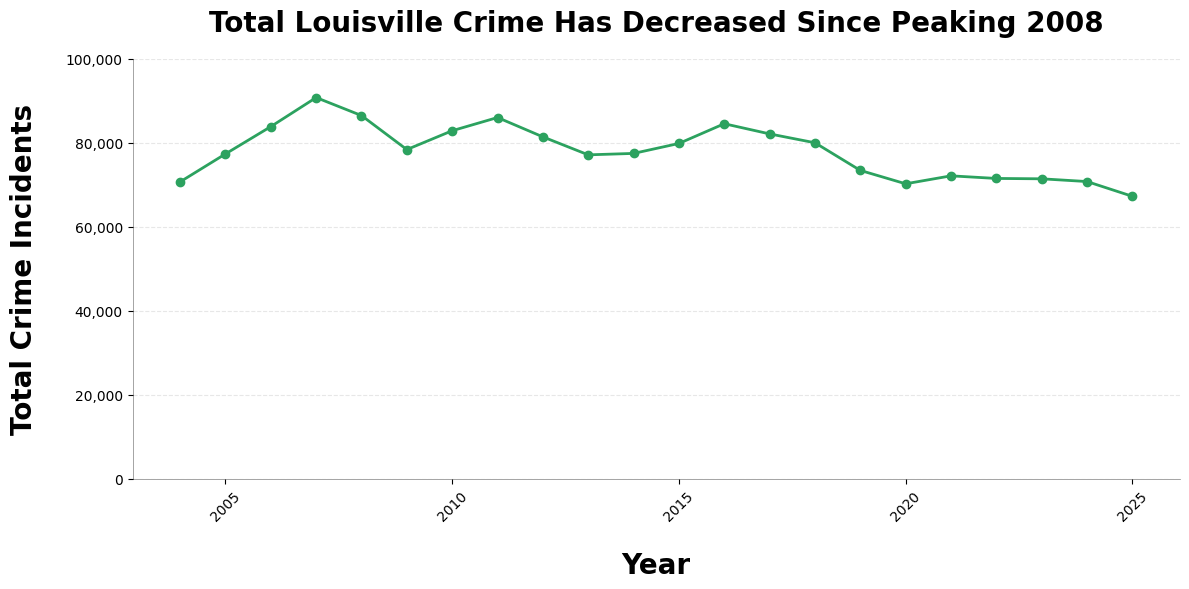

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(crimes_by_year.index,
         crimes_by_year.values,
         marker = "o",
         linestyle = "-",
         color = "#2ca25f",
         linewidth = 2)

plt.xlabel("Year", fontsize=20, labelpad=20, fontweight='bold')
plt.ylabel("Total Crime Incidents", labelpad=20,fontsize=20, fontweight='bold')
plt.title("Total Louisville Crime Has Decreased Since Peaking 2008", fontweight='bold',fontsize=20, pad=20)
plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0,100_000)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Formatting the y axis number with a comma
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## Offense Analysis With Renaming For Continuity 2004 - 2025

- LMPD offense_classification names changed in 2023, expanding from 16 categories to 57. I will need to recategorize and rename classifications so that I can better measure the change over time.

- Additionally, the classification names do not match 1:1. The new names in 2023 include a numeric value which will need to be removed when renamed.

- In 2021 the FBI moved to a new national standard of NIBRS for deeper classification of crime. Louisville adopted this framework shortly after.

In [23]:
# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Create the summary table
summary_df = df_all_years.groupby(['year', 'offense_classification']).size().unstack(fill_value=0)

# Display it
summary_df

offense_classification,1 HOMICIDE,1 NONE,10 KIDNAPPING ONLY,11 SIMPLE ASSAULT,12 INTIMIDATION,13 BURGLARY,14 AUTO THEFT,15 UNAUTHORIZED USE,16 PURSE SNATCH,17 PICK POCKET,18 SHOPLIFTING,19 THEFT FR BLDG,2 NEGLIGENT HOMICIDE,20 THEFT FR VEND MACHINE,21 THEFT FR VEH,22 THEFT MV PARTS,23 LARCENY,23 THEFT OTHER,24 VANDALISM,25 EXTORTION,26 COUNTERFEITING,27 FRAUD,28 FRAUD CREDIT CARD/ATM,29 FRAUD IMPERSONATION,3 JUSTIFIABLE HOMICIDE,32 EMBEZZLEMENT,32 THEFT FR BLDG,33 STOLEN PROPERTY,34 NARCOTICS,35 NARCOTICS EQUIP,36 INCEST,37 STAT RAPE,38 PORNOGRAPHY,4 FORCIBLE RAPE,43 PROSTITUTION,44 PROMOTING PROSTITUTION,45 BRIBERY,46 FAMILY OFFENSES,46 WPNS LAW VIOLATION,47 FAMILY OFFENSES,49 LOITERING/CURFEW VIOL,5 SODOMY FORCE,50 DRUNK DRIVING,51 DISORDERLY CONDUCT,52 DRUNKENNESS,53 LIQUOR LAW VIOLATION,54 VOYEURISM,55 TRESPASSING,56 ALL OTHER CRIMES,56 ALL OTHER OFFENSES,56 NON REPORTABLE,58 ARSON,7 FORCIBLE FONDLING,8 ROBBERY,9 AGGRAVATED ASSAULT,99 NON-REPORTABLE,99 OTHER CRIMES,ARSON,ASSAULT,BURGLARY,DISTURBING THE PEACE,DRUGS/ALCOHOL VIOLATIONS,DUI,FRAUD,HOMICIDE,MOTOR VEHICLE THEFT,OTHER,ROBBERY,SEX CRIMES,THEFT/LARCENY,VANDALISM,VEHICLE BREAK-IN/THEFT,WEAPONS
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,6565,7155,1492,10632,294,2418,72,3345,10459,1471,725,11149,8119,6221,557
2005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,7214,7318,2148,11523,292,3656,64,3364,11667,1859,716,11303,8498,7042,664
2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,7365,7869,2422,13724,314,3737,56,4085,13734,1849,785,12194,7758,7197,744
2007,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,8416,7893,2656,15723,338,3818,77,3616,16874,1982,803,13394,7670,6733,762
2008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,9168,7305,1795,12603,221,3534,75,3040,17316,1833,769,13851,7460,6770,728
2009,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,9220,7141,739,12615,30,3484,68,2106,14203,1624,814,12993,6688,5917,728
2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,10345,7610,553,13452,14,3070,60,2318,14983,1626,643,13815,6638,7012,729
2011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,10490,8080,492,13419,21,3077,50,2623,15844,1661,711,15837,6422,6529,747
2012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,12936,7147,581,16065,7,3070,65,2448,9808,1427,745,15147,5868,5270,818


In [24]:
# Get offense classifications from 2004-2022
offenses_2004_2022 = df_all_years[df_all_years['year'] <= 2022]['offense_classification'].dropna().unique()
offenses_2004_2022_sorted = sorted(offenses_2004_2022)


print("OFFENSE CLASSIFICATIONS FROM 2004-2022")
print(f"Total unique: {len(offenses_2004_2022_sorted)}\n")
for offense in offenses_2004_2022_sorted:
    print(offense)

print("OFFENSE CLASSIFICATIONS FROM 2023-2025")

# Get offense classifications from 2023-2025
offenses_2023_2025 = df_all_years[df_all_years['year'] >= 2023]['offense_classification'].dropna().unique()
offenses_2023_2025_sorted = sorted(offenses_2023_2025)

print(f"Total unique: {len(offenses_2023_2025_sorted)}\n")
for offense in offenses_2023_2025_sorted:
    print(offense)

OFFENSE CLASSIFICATIONS FROM 2004-2022
Total unique: 16

ARSON
ASSAULT
BURGLARY
DISTURBING THE PEACE
DRUGS/ALCOHOL VIOLATIONS
DUI
FRAUD
HOMICIDE
MOTOR VEHICLE THEFT
OTHER
ROBBERY
SEX CRIMES
THEFT/LARCENY
VANDALISM
VEHICLE BREAK-IN/THEFT
WEAPONS
OFFENSE CLASSIFICATIONS FROM 2023-2025
Total unique: 57

1 HOMICIDE
1 NONE
10 KIDNAPPING ONLY
11 SIMPLE ASSAULT
12 INTIMIDATION
13 BURGLARY
14 AUTO THEFT
15 UNAUTHORIZED USE
16 PURSE SNATCH
17 PICK POCKET
18 SHOPLIFTING
19 THEFT FR BLDG
2 NEGLIGENT HOMICIDE
20 THEFT FR VEND MACHINE
21 THEFT FR VEH
22 THEFT MV PARTS
23 LARCENY
23 THEFT OTHER
24 VANDALISM
25 EXTORTION
26 COUNTERFEITING
27 FRAUD
28 FRAUD CREDIT CARD/ATM
29 FRAUD IMPERSONATION
3 JUSTIFIABLE HOMICIDE
32 EMBEZZLEMENT
32 THEFT FR BLDG
33 STOLEN PROPERTY
34 NARCOTICS
35 NARCOTICS EQUIP
36 INCEST
37 STAT RAPE
38 PORNOGRAPHY
4 FORCIBLE RAPE
43 PROSTITUTION
44 PROMOTING PROSTITUTION
45 BRIBERY
46 FAMILY OFFENSES
46 WPNS LAW VIOLATION
47 FAMILY OFFENSES
49 LOITERING/CURFEW VIOL
5 SODOMY FOR

In [25]:
# Create a copy of df_all_years
df_all_years_cleaned = df_all_years.copy()

# Create mapping dictionary for 2023-2025 classifications to match 2004-2022
offense_mapping = {
    # ARSON
    '58 ARSON': 'ARSON',
    
    # ASSAULT
    '10 KIDNAPPING ONLY': 'ASSAULT',
    '11 SIMPLE ASSAULT': 'ASSAULT',
    '9 AGGRAVATED ASSAULT': 'ASSAULT',
    '12 INTIMIDATION': 'ASSAULT',
    
    # BURGLARY
    '13 BURGLARY': 'BURGLARY',
    
    # DISTURBING THE PEACE
    '51 DISORDERLY CONDUCT': 'DISTURBING THE PEACE',
    
    # DRUGS/ALCOHOL VIOLATIONS
    '34 NARCOTICS': 'DRUGS/ALCOHOL VIOLATIONS',
    '35 NARCOTICS EQUIP': 'DRUGS/ALCOHOL VIOLATIONS',
    '52 DRUNKENNESS': 'DRUGS/ALCOHOL VIOLATIONS',
    '53 LIQUOR LAW VIOLATION': 'DRUGS/ALCOHOL VIOLATIONS',
    
    # DUI
    '50 DRUNK DRIVING': 'DUI',
    
    # FRAUD
    '26 COUNTERFEITING': 'FRAUD',
    '27 FRAUD': 'FRAUD',
    '28 FRAUD CREDIT CARD/ATM': 'FRAUD',
    '29 FRAUD IMPERSONATION': 'FRAUD',
    '32 EMBEZZLEMENT': 'FRAUD',
    '45 BRIBERY': 'FRAUD',
    '25 EXTORTION': 'FRAUD',
    
    # HOMICIDE
    '1 HOMICIDE': 'HOMICIDE',
    '2 NEGLIGENT HOMICIDE': 'HOMICIDE',
    '3 JUSTIFIABLE HOMICIDE': 'HOMICIDE',
    
    # MOTOR VEHICLE THEFT
    '14 AUTO THEFT': 'MOTOR VEHICLE THEFT',
    
    # OTHER
    '1 NONE': 'OTHER',
    '15 UNAUTHORIZED USE': 'OTHER',
    '99 OTHER CRIMES': 'OTHER',
    '46 FAMILY OFFENSES': 'OTHER',
    '47 FAMILY OFFENSES': 'OTHER',
    '49 LOITERING/CURFEW VIOL': 'OTHER',
    '55 TRESPASSING': 'OTHER',
    '56 ALL OTHER CRIMES': 'OTHER',
    '56 ALL OTHER OFFENSES': 'OTHER',
    '56 NON REPORTABLE': 'OTHER',
    '99 NON-REPORTABLE': 'OTHER',
    
    # ROBBERY
    '8 ROBBERY': 'ROBBERY',
    
    # SEX CRIMES
    '36 INCEST': 'SEX CRIMES',
    '37 STAT RAPE': 'SEX CRIMES',
    '38 PORNOGRAPHY': 'SEX CRIMES',
    '4 FORCIBLE RAPE': 'SEX CRIMES',
    '5 SODOMY FORCE': 'SEX CRIMES',
    '43 PROSTITUTION': 'SEX CRIMES',
    '44 PROMOTING PROSTITUTION': 'SEX CRIMES',
    '54 VOYEURISM': 'SEX CRIMES',
    '7 FORCIBLE FONDLING': 'SEX CRIMES',
    
    # THEFT/LARCENY
    '17 PICK POCKET': 'THEFT/LARCENY',
    '18 SHOPLIFTING': 'THEFT/LARCENY',
    '19 THEFT FR BLDG': 'THEFT/LARCENY',
    '20 THEFT FR VEND MACHINE': 'THEFT/LARCENY',
    '23 LARCENY': 'THEFT/LARCENY',
    '23 THEFT OTHER': 'THEFT/LARCENY',
    '32 THEFT FR BLDG': 'THEFT/LARCENY',
    '33 STOLEN PROPERTY': 'THEFT/LARCENY',
    '16 PURSE SNATCH': 'THEFT/LARCENY',
    
    # VANDALISM
    '24 VANDALISM': 'VANDALISM',
    
    # VEHICLE BREAK-IN/THEFT
    '22 THEFT MV PARTS': 'VEHICLE BREAK-IN/THEFT',
    '21 THEFT FR VEH': 'VEHICLE BREAK-IN/THEFT',
    
    # WEAPONS
    '46 WPNS LAW VIOLATION': 'WEAPONS',
}

# Apply the mapping to the new dataframe
df_all_years_cleaned['offense_classification'] = df_all_years_cleaned['offense_classification'].replace(offense_mapping)


### Crime started to decrease continually in 2016. What were the top classifications changing comparing 2016 to 2025 vs. 2006 to 2015?

In [55]:
# Define the two periods
period_1 = list(range(2006, 2016))  # 2006-2015 baseline
period_2 = list(range(2016, 2026))  # 2016-2025 post-decline

# Group all classifications by year
crime_by_year_all = (
    df_all_years_cleaned
    .groupby(['year', 'offense_classification'])
    .size()
    .unstack(fill_value=0)
)

# Calculate averages for each period
period_1_avg = crime_by_year_all.loc[crime_by_year_all.index.isin(period_1)].mean()
period_2_avg = crime_by_year_all.loc[crime_by_year_all.index.isin(period_2)].mean()

# Build comparison table
comparison_all = pd.DataFrame({
    '2006–2015 avg': period_1_avg,
    '2016–2025 avg': period_2_avg,
}).round(0).astype(int)

comparison_all['change'] = (
    comparison_all['2016–2025 avg'] - comparison_all['2006–2015 avg']
)
comparison_all['pct_change'] = (
    (comparison_all['2016–2025 avg'] - comparison_all['2006–2015 avg'])
    / comparison_all['2006–2015 avg'] * 100
).round(1)

# Sort by highest declining (most negative pct_change first)
comparison_all = comparison_all.sort_values('pct_change', ascending=True)

# Format for display
comparison_all['pct_change'] = comparison_all['pct_change'].apply(
    lambda x: f"{x:+.1f}%"
)
comparison_all['change'] = comparison_all['change'].apply(
    lambda x: f"{x:+,.0f}"
)
comparison_all['2006–2015 avg'] = comparison_all['2006–2015 avg'].apply(
    lambda x: f"{x:,.0f}"
)
comparison_all['2016–2025 avg'] = comparison_all['2016–2025 avg'].apply(
    lambda x: f"{x:,.0f}"
)

comparison_all.index.name = 'offense_classification'
print(comparison_all.to_string())

                         2006–2015 avg 2016–2025 avg  change pct_change
offense_classification                                                 
DISTURBING THE PEACE             1,081           319    -762     -70.5%
DUI                                 96            30     -66     -68.8%
DRUGS/ALCOHOL VIOLATIONS        14,138         7,860  -6,278     -44.4%
BURGLARY                         7,308         4,466  -2,842     -38.9%
ROBBERY                          1,667         1,158    -509     -30.5%
OTHER                           12,557         9,729  -2,828     -22.5%
SEX CRIMES                         709           564    -145     -20.5%
THEFT/LARCENY                   14,549        13,148  -1,401      -9.6%
VANDALISM                        6,490         6,065    -425      -6.5%
VEHICLE BREAK-IN/THEFT           6,049         5,965     -84      -1.4%
FRAUD                            3,520         3,732    +212      +6.0%
WEAPONS                            800         1,148    +348    

### In 2016 officers or people stopped calling on Disturbing the Peace, Drug/Alcohol violations, Burglary, and Other (minor offenses)
The offenses that increased were Weapons, Assault, Motor Vehicle Theft, Homicide, and Arson but these increases did not offset the declines.

- Key drivers ideation:

- Number of officers is stable but retention has struggled from 2020-2023 and hiring struggles.
- Did officers not respond to calls or did calls stop occurring?
- Did population increase at the same rate as hiring for police? Are these factors correlated?

- In 2016 8 states passed marijuana legalization which impacted federal focus on drug/alcohol violations.
- Other police initiatives in 2016 included: increased use of body-worn cameras, new training on the use of force, and improved reporting on police operations.
- Data Reporting Shift: The FBI began transitioning to a new data system (NIBRS) to provide more comprehensive data on victims and offenders, including incidents of identity theft and animal cruelty
- Black Lives Matter, Mass Shootings, Race Shootings, Trump's Law and Order campaign are all in the mix for impacting local policing policies and cultural attitudes toward police.
- Breonna Taylor protests occurred in 2020 in Louisville, driving further policing skepticism and distrust, possibly impacting recruitment and effort.

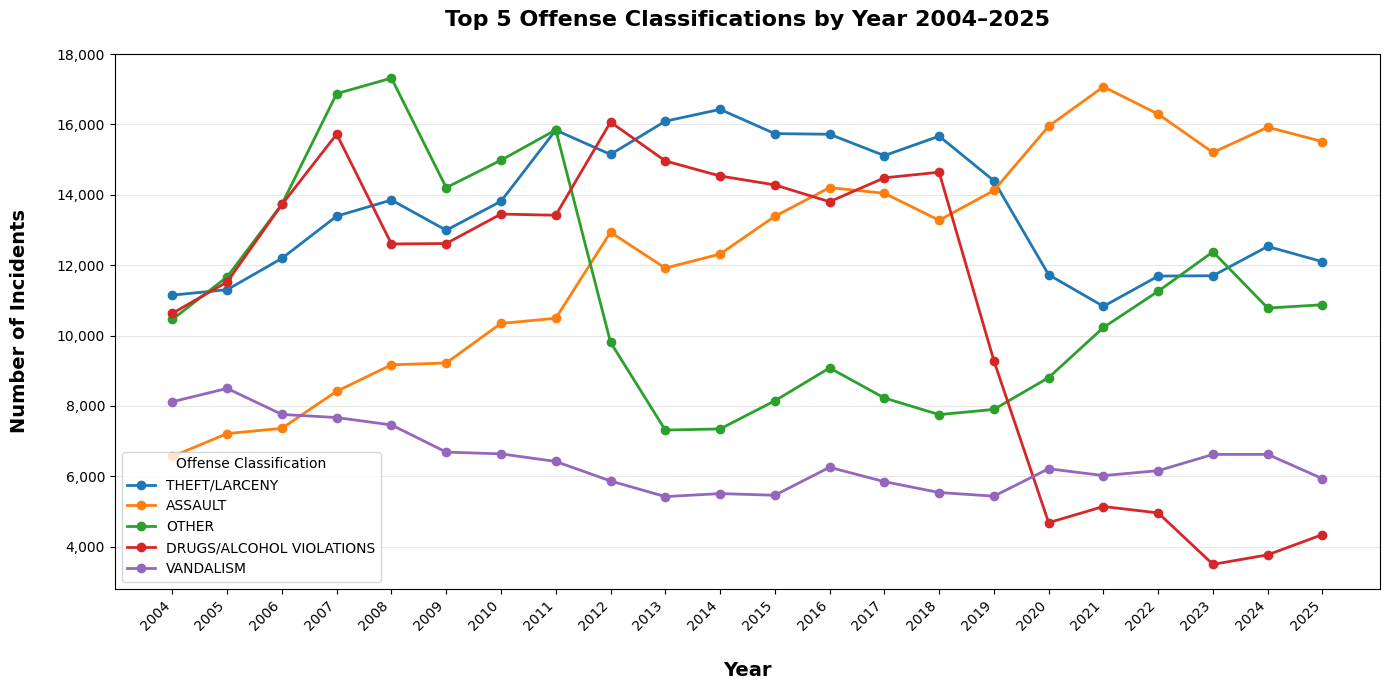

Top 5 classifications:
  1. THEFT/LARCENY: 299,415 total incidents
  2. ASSAULT: 270,929 total incidents
  3. OTHER: 244,982 total incidents
  4. DRUGS/ALCOHOL VIOLATIONS: 242,138 total incidents
  5. VANDALISM: 142,168 total incidents


In [ ]:
# Get top 5 offense classifications by total incidents across all years
top_5_offenses = (
    df_all_years_cleaned['offense_classification']
    .value_counts()
    .nlargest(5)
    .index.tolist()
)

# Filter to top 5 and group by year
crime_by_year = (
    df_all_years_cleaned[df_all_years_cleaned['offense_classification'].isin(top_5_offenses)]
    .groupby(['year', 'offense_classification'])
    .size()
    .unstack(fill_value=0)
)

# Create line chart
fig, ax = plt.subplots(figsize=(14, 7))

for offense in top_5_offenses:
    ax.plot(
        crime_by_year.index,
        crime_by_year[offense],
        marker='o',
        linewidth=2,
        label=offense
    )

ax.set_xlabel('Year', labelpad=20, fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Incidents', labelpad=20, fontsize=14, fontweight='bold')
ax.set_title('Top 5 Offense Classifications by Year 2004–2025',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(title='Offense Classification', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.xticks(crime_by_year.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 classifications:")
for i, offense in enumerate(top_5_offenses, 1):
    count = df_all_years_cleaned[
        df_all_years_cleaned['offense_classification'] == offense
    ].shape[0]
    print(f"  {i}. {offense}: {count:,} total incidents")


### What is in the category of 'Other'

In [51]:
# Show all offense_code_name values that map to OTHER classification
other_crimes = (
    df_all_years_cleaned[df_all_years_cleaned['offense_classification'] == 'OTHER']
    ['offense_code_name']
    .value_counts()
    .reset_index()
)
other_crimes.columns = ['offense_code_name', 'count']
print(f"Total OTHER incidents: {other_crimes['count'].sum():,}")
print(f"Unique offense types in OTHER: {len(other_crimes):,}\n")
other_crimes.head(30)

Total OTHER incidents: 244,982
Unique offense types in OTHER: 1,098



,offense_code_name,count
0,MISSING PERSONS,34510
1,DOMESTIC ABUSE DUTIES OF LAW ENFORCEMENT,31702
2,DOMESTIC ABUSE DUTIES OF LAW ENFORCEMENT 403.785 03018 90Z,16689
3,HARASSING COMMUNICATIONS,12090
4,LEAVING SCENE OF ACCIDENT - HIT & RUN,11376
5,PROPERTY LOST OR ABANDONED NON CRIMINAL,11221
6,ANY NON CRIMINAL CHARGE NOT COVERED BY THESE CODES,8926
7,LEAVING SCENE OF ACCIDENT/FAILURE TO RENDER AID OR ASSISTANC,7269
8,DEATH INVESTIGATION,7179
9,RECOVERY OF STOLEN VEHICLE-OUT OF JURISDICTION,5480


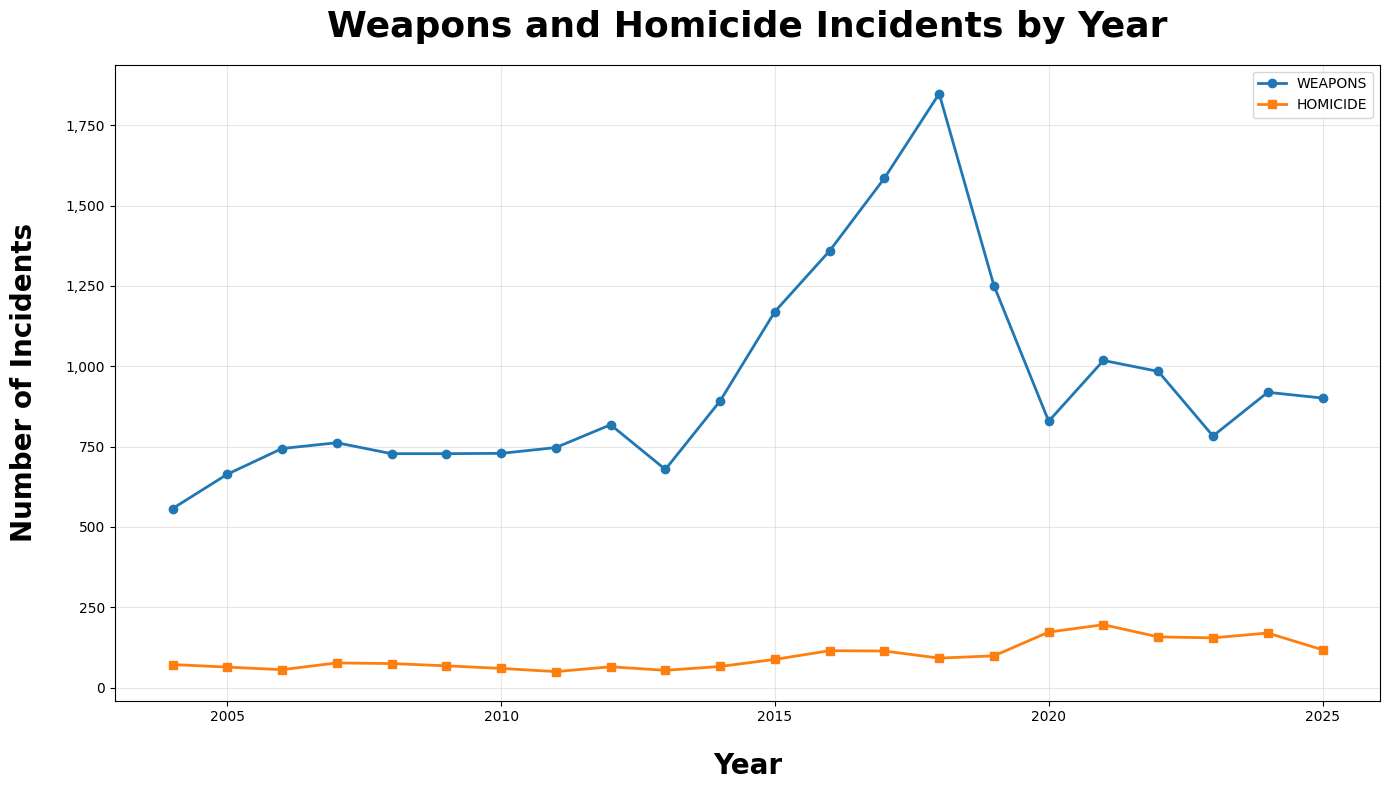

In [27]:
# Create summary by year for WEAPONS and HOMICIDE
weapons_homicide = df_all_years_cleaned[df_all_years_cleaned['offense_classification'].isin(['WEAPONS', 'HOMICIDE'])]

# Group by year and offense classification
summary = weapons_homicide.groupby(['year', 'offense_classification']).size().unstack(fill_value=0)

# Create line chart
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(summary.index, summary['WEAPONS'], marker='o', linewidth=2, label='WEAPONS')
ax.plot(summary.index, summary['HOMICIDE'], marker='s', linewidth=2, label='HOMICIDE')

ax.set_xlabel('Year', labelpad=20,fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Incidents', labelpad=20,fontsize=20, fontweight='bold')
ax.set_title('Weapons and Homicide Incidents by Year', pad=20,fontsize=26, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

# Analysis of Crime Trends With API Calls and Data Joins For Socioeconomic Data From Census Bureau

## API Call For ACS 5-year Data (2012 - 2023)
- Pulling 32 zips in Louisville

In [28]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
key = os.getenv("CENSUS_API_KEY")
print("Key loaded:", "YES" if key else "NO")

# Louisville-area ZIP codes (ZCTAs)
louisville_zips = [
    "40202", "40203", "40204", "40205", "40206", "40207", "40208", "40209",
    "40210", "40211", "40212", "40213", "40214", "40215", "40216", "40217",
    "40218", "40219", "40220", "40221", "40222", "40223", "40224", "40225",
    "40228", "40229", "40231", "40232", "40233", "40241", "40242", "40243",
    "40245", "40258", "40272", "40291", "40299"
]

# ACS variables to pull — Census variable codes mapped to human-readable names.
# To browse all available variables: https://api.census.gov/data/2022/acs/acs5/variables.html
VARIABLES = {
    # Core demographics
    "B01003_001E": "total_population",
    "B01002_001E": "median_age",

    # Income & poverty
    "B19013_001E": "median_household_income",
    "B17001_002E": "population_below_poverty",

    # Housing
    "B25077_001E": "median_home_value",        # Not available in 2011 — handled below
    "B25070_010E": "rent_burden_50pct_plus",   # Households paying 50%+ income on rent

    # Education
    "B15003_002E": "no_schooling",
    "B15003_021E": "associates_degree",
    "B15003_022E": "bachelors_degree",
    "B15003_023E": "masters_degree",
    "B15003_025E": "professional_degree",

    # Employment
    "B23025_005E": "unemployed_population",    # Civilian unemployed, in labor force

    # Household structure
    "B11001_006E": "single_parent_households", # Female householder, no spouse present

    # Residential mobility — population that moved in the past year
    "B07003_004E": "moved_past_year",
}

# Variables not available in 2011 — will be excluded for that year only.
# Affected rows will have NaN for these columns in 2011.
UNAVAILABLE_2011 = {"B25077_001E", "B25070_010E", "B07003_004E"}

# 2009-2010 don't support ZIP geography in ACS 5-year.
# 2011 is available but missing some variables (see UNAVAILABLE_2011).
years = list(range(2011, 2024))


def pull_acs_year(year):
    """Pull ACS 5-year data for all ZCTAs via raw API call, filter to Louisville."""

    # Drop variables known to be unavailable in 2011 to avoid 400 errors
    if year == 2011:
        variables = {k: v for k, v in VARIABLES.items() if k not in UNAVAILABLE_2011}
    else:
        variables = VARIABLES

    var_list = "NAME," + ",".join(variables.keys())
    url = (
        f"https://api.census.gov/data/{year}/acs/acs5"
        f"?get={var_list}"
        f"&for=zip%20code%20tabulation%20area:*"
        f"&key={key}"
    )

    try:
        r = requests.get(url)
        r.raise_for_status()
        data = r.json()

        # First row from Census API is always the header row
        headers = data[0]
        rows = data[1:]
        df = pd.DataFrame(rows, columns=headers)

        # Filter down to Louisville ZCTAs only
        df = df[df["zip code tabulation area"].isin(louisville_zips)].copy()
        df = df.rename(columns={"zip code tabulation area": "zip_code"})
        df = df.rename(columns=variables)
        df["year"] = year

        # Convert all variable columns to numeric.
        # errors="coerce" turns any non-numeric values into NaN.
        numeric_cols = list(variables.values())
        df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

        # Census uses -666666666 as a sentinel for suppressed/unavailable data.
        # Replace with NaN so it doesn't distort calculations.
        df[numeric_cols] = df[numeric_cols].replace(-666666666, pd.NA)

        # --- Derived fields ---

        # Poverty rate as a percentage of total population
        df["poverty_rate"] = (
            df["population_below_poverty"] / df["total_population"] * 100
        ).round(2)

        # % of population with bachelor's degree or higher
        df["pct_bachelors_plus"] = (
            (df["bachelors_degree"] + df["masters_degree"] +
             df["professional_degree"]) / df["total_population"] * 100
        ).round(2)

        # Unemployment rate as a percentage of total population
        df["unemployment_rate"] = (
            df["unemployed_population"] / df["total_population"] * 100
        ).round(2)

        # Residential mobility rate — % of population that moved in past year
        df["mobility_rate"] = (
            df["moved_past_year"] / df["total_population"] * 100
        ).round(2) if "moved_past_year" in df.columns else pd.NA

        print(f"  {year}: {len(df)} ZIPs pulled")
        return df

    except Exception as e:
        print(f"  {year}: FAILED — {e}")
        return None


def build_demographics_table():
    """Loop through all years, pull ACS data, and combine into one DataFrame."""
    frames = []
    for year in years:
        print(f"Pulling {year}...")
        df = pull_acs_year(year)
        if df is not None:
            frames.append(df)

    if not frames:
        raise ValueError("No data was pulled — check your API key and connection.")

    combined = pd.concat(frames, ignore_index=True)

    # Warn about any columns with more than 20% missing values across all rows.
    # Per project plan, avoid drawing insights from these fields.
    missing_pct = combined.isnull().mean()
    high_missing = missing_pct[missing_pct > 0.2].index.tolist()
    if high_missing:
        print(f"\nWarning: High missing data in columns: {high_missing}")

    return combined


# Pull ACS data and save to CSV — only needs to run once
print("Pulling ACS 5-year data for Louisville ZIPs...\n")
df_demographics_raw = build_demographics_table()

os.makedirs("data", exist_ok=True)
df_demographics_raw.to_csv("data/louisville_demographics.csv", index=False)
print(f"\nDone. {len(df_demographics_raw):,} rows saved.")

Key loaded: YES
Pulling ACS 5-year data for Louisville ZIPs...

Pulling 2011...
  2011: FAILED — 400 Client Error:  for url: https://api.census.gov/data/2011/acs/acs5?get=NAME,B01003_001E,B01002_001E,B19013_001E,B17001_002E,B15003_002E,B15003_021E,B15003_022E,B15003_023E,B15003_025E,B23025_005E,B11001_006E&for=zip%20code%20tabulation%20area:*&key=e9d4b6f4dd0dbeab73515ae32f4cb33ed4ab5dba
Pulling 2012...
  2012: 32 ZIPs pulled
Pulling 2013...
  2013: 32 ZIPs pulled
Pulling 2014...
  2014: 32 ZIPs pulled
Pulling 2015...
  2015: 32 ZIPs pulled
Pulling 2016...
  2016: 32 ZIPs pulled
Pulling 2017...
  2017: 32 ZIPs pulled
Pulling 2018...
  2018: 32 ZIPs pulled
Pulling 2019...
  2019: 32 ZIPs pulled
Pulling 2020...
  2020: 32 ZIPs pulled
Pulling 2021...
  2021: 33 ZIPs pulled
Pulling 2022...
  2022: 33 ZIPs pulled
Pulling 2023...
  2023: 33 ZIPs pulled


Done. 387 rows saved.


# Prep for SQL work

## Create df for demographics

In [29]:
# Load demographics from notebooks/data/
df_demographics = pd.read_csv('data/louisville_demographics.csv')
print(f"Demographics loaded: {len(df_demographics):,} rows")

df_demographics.head()


Demographics loaded: 387 rows


,NAME,total_population,median_age,median_household_income,population_below_poverty,median_home_value,rent_burden_50pct_plus,no_schooling,associates_degree,bachelors_degree,masters_degree,professional_degree,unemployed_population,single_parent_households,moved_past_year,state,zip_code,year,poverty_rate,pct_bachelors_plus,unemployment_rate,mobility_rate
0,ZCTA5 40202,6429,34.4,16466.0,1889,290600.0,462,21,178,623,193,139,299,359,3434,21.0,40202,2012,29.38,14.85,4.65,53.41
1,ZCTA5 40203,19270,33.3,16036.0,9733,80700.0,1694,178,715,860,358,150,1941,2479,14874,21.0,40203,2012,50.51,7.10,10.07,77.19
2,ZCTA5 40204,14480,38.3,46012.0,2078,162500.0,628,38,492,2716,1639,293,716,569,11194,21.0,40204,2012,14.35,32.10,4.94,77.31
3,ZCTA5 40205,23483,42.4,66624.0,1742,235400.0,591,60,953,5375,2847,710,542,857,19804,21.0,40205,2012,7.42,38.04,2.31,84.33
4,ZCTA5 40206,18474,39.5,43817.0,2642,171000.0,885,69,855,3740,1962,469,750,834,14804,21.0,40206,2012,14.30,33.40,4.06,80.13


# Standardize zip code format for joining

In [30]:


# Standardize zip_code to clean string in crime data
# Use .loc to avoid the length mismatch error
# Convert float strings like 40210.0 -> "40210", leave NaN as NaN
df_all_years_cleaned['zip_code'] = (
    df_all_years_cleaned['zip_code']
    .astype(str)                        # convert everything to string first
    .str.replace(r'\.0$', '', regex=True)  # strip the .0 from floats
    .str.strip()                        # remove any whitespace
    .replace('nan', None)               # put NaN back as None
)

# Standardize zip_code in demographics to string
df_demographics['zip_code'] = df_demographics['zip_code'].astype(str).str.strip()

# Verify both match
print("\nSample zip_codes from crime data:")
print(df_all_years_cleaned['zip_code'].dropna().head(5).tolist())

print("\nSample zip_codes from demographics:")
print(df_demographics['zip_code'].head(5).tolist())


Sample zip_codes from crime data:
['40210', '40208', '40210', '40210', '40218']

Sample zip_codes from demographics:
['40202', '40203', '40204', '40205', '40206']


# Build the schema

In [31]:
# Database file will live in project root data/ folder
DB_PATH = '../data/lou_crime.db'

# This is the schema — it defines the structure of each table
# No data is loaded here, just the blueprints
SCHEMA = """

-- Lookup table: the 13 standardized crime classifications
-- Small table, just unique category names
CREATE TABLE IF NOT EXISTS crime_type (
    classification_id       INTEGER PRIMARY KEY AUTOINCREMENT,
    offense_classification  TEXT NOT NULL UNIQUE
);

-- Lookup table: location categories (e.g. HIGHWAY, RESIDENCE)
-- Small table, just unique location types
CREATE TABLE IF NOT EXISTS crime_location (
    location_id             INTEGER PRIMARY KEY AUTOINCREMENT,
    location_category       TEXT NOT NULL UNIQUE
);

-- Lookup table: LMPD divisions and beats
-- Small table, unique combinations of division + beat
CREATE TABLE IF NOT EXISTS lmpd_division (
    division_id             INTEGER PRIMARY KEY AUTOINCREMENT,
    lmpd_division           TEXT NOT NULL,
    lmpd_beat               TEXT,
    UNIQUE(lmpd_division, lmpd_beat)
);

-- Dimension table: ACS census demographics
-- One row per ZIP code per year — joined to crime_summary on zip_code + year
CREATE TABLE IF NOT EXISTS zip_code_demographics (
    demo_id                     INTEGER PRIMARY KEY AUTOINCREMENT,
    zip_code                    TEXT NOT NULL,
    year                        INTEGER NOT NULL,
    total_population            REAL,
    median_age                  REAL,
    median_household_income     REAL,
    median_home_value           REAL,
    population_below_poverty    REAL,
    poverty_rate                REAL,
    no_schooling                REAL,
    associates_degree           REAL,
    bachelors_degree            REAL,
    masters_degree              REAL,
    professional_degree         REAL,
    pct_bachelors_plus          REAL,
    unemployed_population       REAL,
    unemployment_rate           REAL,
    single_parent_households    REAL,
    moved_past_year             REAL,
    mobility_rate               REAL,
    rent_burden_50pct_plus      REAL,
    UNIQUE(zip_code, year)
);

-- Fact table: one row per crime incident — 1.7M rows
-- References the three lookup tables via foreign keys
CREATE TABLE IF NOT EXISTS crime_incidents (
    incident_id             INTEGER PRIMARY KEY AUTOINCREMENT,
    incident_number         TEXT,
    date_reported           TEXT,
    date_occurred           TEXT,
    year                    INTEGER,
    offense_code_name       TEXT,
    was_offense_completed   TEXT,
    block_address           TEXT,
    city                    TEXT,
    zip_code                TEXT,
    classification_id       INTEGER REFERENCES crime_type(classification_id),
    location_id             INTEGER REFERENCES crime_location(location_id),
    division_id             INTEGER REFERENCES lmpd_division(division_id)
);

-- Aggregated summary: incident counts per ZIP per year per classification
-- This is the key analytical table — joins directly to zip_code_demographics
CREATE TABLE IF NOT EXISTS crime_summary (
    summary_id              INTEGER PRIMARY KEY AUTOINCREMENT,
    zip_code                TEXT NOT NULL,
    year                    INTEGER NOT NULL,
    offense_classification  TEXT NOT NULL,
    incident_count          INTEGER NOT NULL,
    UNIQUE(zip_code, year, offense_classification)
);
"""

# Connect to the database file — creates it if it doesn't exist
conn = sqlite3.connect(DB_PATH)

# Run the schema — this creates all the empty tables
conn.executescript(SCHEMA)
conn.commit()

# Verify tables were created
tables = [row[0] for row in conn.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()]
print("Schema created. Tables:", tables)

Schema created. Tables: ['crime_type', 'sqlite_sequence', 'crime_location', 'lmpd_division', 'zip_code_demographics', 'crime_incidents', 'crime_summary']


## Load the data into tables

In [32]:
# Load the three small lookup tables first
# These have no dependencies so they go in first

# crime_type: unique offense classifications from the cleaned crime data
crime_types = (
    df_all_years_cleaned[['offense_classification']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)
crime_types.to_sql('crime_type', conn, if_exists='append', index=False)
print(f"crime_type:     {len(crime_types)} rows")

# crime_location: unique location categories
locations = (
    df_all_years_cleaned[['location_category']]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)
locations.to_sql('crime_location', conn, if_exists='append', index=False)
print(f"crime_location: {len(locations)} rows")

# lmpd_division: unique division + beat combinations
divisions = (
    df_all_years_cleaned[['lmpd_division', 'lmpd_beat']]
    .dropna(subset=['lmpd_division'])
    .drop_duplicates()
    .reset_index(drop=True)
)
divisions.to_sql('lmpd_division', conn, if_exists='append', index=False)
print(f"lmpd_division:  {len(divisions)} rows")

# Step 2: Build foreign key mappings
# Read the lookup tables back from SQL to get their auto-generated IDs
# Then map those IDs onto the crime dataframe before loading incidents

ct_map = pd.read_sql("SELECT classification_id, offense_classification FROM crime_type", conn)
ct_map = dict(zip(ct_map['offense_classification'], ct_map['classification_id']))

loc_map = pd.read_sql("SELECT location_id, location_category FROM crime_location", conn)
loc_map = dict(zip(loc_map['location_category'], loc_map['location_id']))

div_map = pd.read_sql("SELECT division_id, lmpd_division, lmpd_beat FROM lmpd_division", conn)
div_map = {(r['lmpd_division'], r['lmpd_beat']): r['division_id']
           for _, r in div_map.iterrows()}

# Map the IDs onto the crime dataframe as new columns
df_all_years_cleaned['classification_id'] = df_all_years_cleaned['offense_classification'].map(ct_map)
df_all_years_cleaned['location_id'] = df_all_years_cleaned['location_category'].map(loc_map)
df_all_years_cleaned['division_id'] = df_all_years_cleaned.apply(
    lambda r: div_map.get((r['lmpd_division'], r['lmpd_beat'])), axis=1
)

# Step 3: Load crime_incidents fact table
# Select only the columns that belong in this table
incident_cols = [
    'incident_number', 'date_reported', 'date_occurred', 'year',
    'offense_code_name', 'was_offense_completed', 'block_address',
    'city', 'zip_code', 'classification_id', 'location_id', 'division_id'
]
incidents = df_all_years_cleaned[incident_cols]
incidents.to_sql('crime_incidents', conn, if_exists='append', index=False)
print(f"crime_incidents: {len(incidents):,} rows")

# Step 4: Build and load crime_summary
# Group by ZIP + year + classification and count incidents
# This is pre-aggregated so queries run fast
summary = (
    df_all_years_cleaned
    .groupby(['zip_code', 'year', 'offense_classification'])
    .size()
    .reset_index(name='incident_count')
)
summary = summary[summary['zip_code'].notna() & summary['year'].notna()]
summary.to_sql('crime_summary', conn, if_exists='append', index=False)
print(f"crime_summary:   {len(summary):,} rows")

# Step 5: Load demographics
# Drop any leftover Census API columns not in the schema
demo_cols_to_drop = ['state', 'NAME', 'name']
df_demographics_clean = df_demographics.drop(
    columns=[c for c in demo_cols_to_drop if c in df_demographics.columns]
)
df_demographics_clean.to_sql('zip_code_demographics', conn, if_exists='append', index=False)
print(f"zip_code_demographics: {len(df_demographics_clean):,} rows")

# Commit and close
conn.commit()
conn.close()
print(f"\nDone. Database saved to {DB_PATH}")
print("Open lou_crime.db in SQLiteStudio to verify.")

IntegrityError: UNIQUE constraint failed: crime_type.offense_classification

# SQL Queries

### Query 1 — Core Analytical Table
**Type:** Aggregation + Join  
Joins the `crime_summary` fact table to `zip_code_demographics` on ZIP code and year, 
producing one row per ZIP per year with total incident counts and all socioeconomic indicators 
side by side. A crime rate per 1,000 people is calculated to normalize incident counts across 
ZIP codes of different population sizes, enabling fair comparison between dense urban ZIPs and 
smaller suburban ones. This table is the foundation for all downstream correlation and 
regression analysis.

---

### Query 2 — Crime Trends by Classification Over Time
**Type:** Aggregation + Join + Window Function  
Extends the core table by breaking crime down by offense classification for each ZIP and year. 
A window function calculates the citywide average crime rate for each year in parallel, allowing 
each row to be compared against the Louisville average without a separate subquery. This query 
supports analysis of which crime types are driving overall trends and which ZIPs consistently 
sit above or below the citywide average across classifications.

---

### Query 3 — ZIP Socioeconomic Profile with Crime Context
**Type:** CTE + Join  
Uses two Common Table Expressions (CTEs) to first calculate ZIP-level crime and socioeconomic 
metrics, then calculate citywide averages by year. Each ZIP is then assigned a profile label 
based on how its poverty rate and crime rate compare to the citywide average for that year:

- **High poverty / High crime** — ZIP is above average on both metrics
- **High poverty / Low crime** — ZIP has elevated poverty but below average crime (opportunity zone)
- **Low poverty / High crime** — ZIP has low poverty but elevated crime (outlier)
- **Low poverty / Low crime** — ZIP is below average on both metrics

This profiling directly addresses the project's core research question of whether socioeconomic 
factors predict crime rates, and identifies ZIP codes where the relationship breaks down — 
the opportunity zone concept outlined in the project plan.

In [33]:
# SQL Query 1 — Core Analytical Table
# Aggregation + Join
# Joins crime summary to demographics for every ZIP and year.
# Calculates crime rate per 1,000 people for fair cross-ZIP comparison.

conn = sqlite3.connect('../data/lou_crime.db')

df_core = pd.read_sql("""
    SELECT
        cs.zip_code,
        cs.year,
        SUM(cs.incident_count)              AS total_incidents,
        zd.total_population,
        zd.median_household_income,
        zd.poverty_rate,
        zd.unemployment_rate,
        zd.pct_bachelors_plus,
        zd.single_parent_households,
        zd.mobility_rate,
        zd.rent_burden_50pct_plus,
        zd.median_home_value,
        ROUND(
            SUM(cs.incident_count) * 1000.0 / NULLIF(zd.total_population, 0), 2
        ) AS crime_rate_per_1000
    FROM crime_summary cs
    JOIN zip_code_demographics zd
        ON cs.zip_code = zd.zip_code
        AND cs.year = zd.year
    GROUP BY
        cs.zip_code, cs.year, zd.total_population,
        zd.median_household_income, zd.poverty_rate,
        zd.unemployment_rate, zd.pct_bachelors_plus,
        zd.single_parent_households, zd.mobility_rate,
        zd.rent_burden_50pct_plus, zd.median_home_value
    ORDER BY cs.zip_code, cs.year
""", conn)

print(f"Rows returned: {len(df_core):,}")
df_core.head(10)

Rows returned: 373


,zip_code,year,total_incidents,total_population,median_household_income,poverty_rate,unemployment_rate,pct_bachelors_plus,single_parent_households,mobility_rate,rent_burden_50pct_plus,median_home_value,crime_rate_per_1000
0,40202,2012,3316,6429.0,16466.0,29.38,4.65,14.85,359.0,53.41,462.0,290600.0,515.79
1,40202,2013,3478,6442.0,16069.0,30.91,7.44,11.84,384.0,53.35,522.0,279500.0,539.89
2,40202,2014,3109,6468.0,14619.0,32.93,7.64,9.79,442.0,55.32,497.0,299000.0,480.67
3,40202,2015,3290,6362.0,14738.0,32.73,8.22,10.22,432.0,55.11,406.0,469400.0,517.13
4,40202,2016,3611,6411.0,16500.0,33.02,8.69,11.40,474.0,59.13,411.0,327800.0,563.25
5,40202,2017,3380,6827.0,17372.0,30.25,7.54,10.21,489.0,55.98,384.0,262500.0,495.09
6,40202,2018,3693,7176.0,17940.0,30.13,5.60,10.56,467.0,55.78,350.0,282000.0,514.63
7,40202,2019,3549,7194.0,19628.0,28.23,5.17,12.72,330.0,51.63,339.0,290600.0,493.33
8,40202,2020,2887,7796.0,17295.0,29.82,3.71,13.10,321.0,54.80,270.0,310200.0,370.32
9,40202,2021,2898,7444.0,20755.0,28.96,2.79,14.00,262.0,57.93,270.0,319600.0,389.31


In [34]:
# SQL Query 2 — Crime Trends by Classification Over Time
# Aggregation + Join + Window Function
# Breaks crime down by type for each ZIP and year.
# Compares each row against the citywide average rate for that year
# using a window function — identifies which ZIPs are above or below average.

df_classification = pd.read_sql("""
    SELECT
        cs.zip_code,
        cs.year,
        cs.offense_classification,
        cs.incident_count,
        zd.poverty_rate,
        zd.median_household_income,
        ROUND(
            cs.incident_count * 1000.0 / NULLIF(zd.total_population, 0), 2
        ) AS crime_rate_per_1000,
        ROUND(
            AVG(cs.incident_count * 1000.0 / NULLIF(zd.total_population, 0))
                OVER (PARTITION BY cs.year), 2
        ) AS avg_citywide_rate
    FROM crime_summary cs
    JOIN zip_code_demographics zd
        ON cs.zip_code = zd.zip_code
        AND cs.year = zd.year
    ORDER BY cs.zip_code, cs.year, cs.offense_classification
""", conn)

print(f"Rows returned: {len(df_classification):,}")
df_classification.head(10)

Rows returned: 5,307


,zip_code,year,offense_classification,incident_count,poverty_rate,median_household_income,crime_rate_per_1000,avg_citywide_rate
0,40202,2012,ASSAULT,448,29.38,16466.0,69.68,9.84
1,40202,2012,BURGLARY,88,29.38,16466.0,13.69,9.84
2,40202,2012,DISTURBING THE PEACE,8,29.38,16466.0,1.24,9.84
3,40202,2012,DRUGS/ALCOHOL VIOLATIONS,693,29.38,16466.0,107.79,9.84
4,40202,2012,DUI,1,29.38,16466.0,0.16,9.84
5,40202,2012,FRAUD,79,29.38,16466.0,12.29,9.84
6,40202,2012,HOMICIDE,1,29.38,16466.0,0.16,9.84
7,40202,2012,MOTOR VEHICLE THEFT,133,29.38,16466.0,20.69,9.84
8,40202,2012,OTHER,418,29.38,16466.0,65.02,9.84
9,40202,2012,ROBBERY,79,29.38,16466.0,12.29,9.84


In [35]:
# SQL Query 3 — ZIP Socioeconomic Profile with Crime Context
# CTE (Common Table Expression) + Join + Subquery
# Uses two CTEs to calculate ZIP level metrics and citywide averages.
# Assigns each ZIP a profile label based on how its poverty rate and
# crime rate compare to the citywide average for that year.
# This directly surfaces the opportunity zone concept from the project plan —
# identifying ZIPs where crime and socioeconomic conditions diverge.

df_profiles = pd.read_sql("""
    WITH zip_ranked AS (
        SELECT
            cs.zip_code,
            cs.year,
            SUM(cs.incident_count)          AS total_incidents,
            zd.total_population,
            zd.poverty_rate,
            zd.median_household_income,
            zd.unemployment_rate,
            zd.pct_bachelors_plus,
            zd.single_parent_households,
            ROUND(
                SUM(cs.incident_count) * 1000.0 / NULLIF(zd.total_population, 0), 2
            ) AS crime_rate_per_1000
        FROM crime_summary cs
        JOIN zip_code_demographics zd
            ON cs.zip_code = zd.zip_code
            AND cs.year = zd.year
        GROUP BY
            cs.zip_code, cs.year, zd.total_population,
            zd.poverty_rate, zd.median_household_income,
            zd.unemployment_rate, zd.pct_bachelors_plus,
            zd.single_parent_households
    ),
    citywide_avg AS (
        SELECT
            year,
            AVG(crime_rate_per_1000)        AS avg_crime_rate,
            AVG(poverty_rate)               AS avg_poverty_rate,
            AVG(median_household_income)    AS avg_income
        FROM zip_ranked
        GROUP BY year
    )
    SELECT
        zr.zip_code,
        zr.year,
        zr.crime_rate_per_1000,
        zr.poverty_rate,
        zr.median_household_income,
        zr.unemployment_rate,
        zr.pct_bachelors_plus,
        zr.single_parent_households,
        ROUND(ca.avg_crime_rate, 2)         AS avg_citywide_crime_rate,
        ROUND(ca.avg_poverty_rate, 2)       AS avg_citywide_poverty_rate,
        ROUND(ca.avg_income, 2)             AS avg_citywide_income,
        CASE
            WHEN zr.poverty_rate > ca.avg_poverty_rate
            AND zr.crime_rate_per_1000 < ca.avg_crime_rate
            THEN 'High poverty / Low crime'
            WHEN zr.poverty_rate < ca.avg_poverty_rate
            AND zr.crime_rate_per_1000 > ca.avg_crime_rate
            THEN 'Low poverty / High crime'
            WHEN zr.poverty_rate > ca.avg_poverty_rate
            AND zr.crime_rate_per_1000 > ca.avg_crime_rate
            THEN 'High poverty / High crime'
            ELSE 'Low poverty / Low crime'
        END AS zip_profile
    FROM zip_ranked zr
    JOIN citywide_avg ca ON zr.year = ca.year
    ORDER BY zr.year, zr.crime_rate_per_1000 DESC
""", conn)

conn.close()
print(f"Rows returned: {len(df_profiles):,}")
df_profiles.head(10)

Rows returned: 373


,zip_code,year,crime_rate_per_1000,poverty_rate,median_household_income,unemployment_rate,pct_bachelors_plus,single_parent_households,avg_citywide_crime_rate,avg_citywide_poverty_rate,avg_citywide_income,zip_profile
0,40209,2012,516.84,46.27,37009.0,6.73,6.88,35.0,136.22,18.6,47297.9,High poverty / High crime
1,40202,2012,515.79,29.38,16466.0,4.65,14.85,359.0,136.22,18.6,47297.9,High poverty / High crime
2,40203,2012,302.39,50.51,16036.0,10.07,7.10,2479.0,136.22,18.6,47297.9,High poverty / High crime
3,40211,2012,240.62,37.56,22461.0,9.47,5.78,3444.0,136.22,18.6,47297.9,High poverty / High crime
4,40212,2012,224.12,34.13,26843.0,9.14,3.79,2615.0,136.22,18.6,47297.9,High poverty / High crime
5,40208,2012,212.36,32.80,25533.0,6.11,11.30,950.0,136.22,18.6,47297.9,High poverty / High crime
6,40210,2012,206.22,45.06,19742.0,9.65,4.77,2296.0,136.22,18.6,47297.9,High poverty / High crime
7,40215,2012,167.38,34.94,26628.0,11.16,4.69,2545.0,136.22,18.6,47297.9,High poverty / High crime
8,40204,2012,165.88,14.35,46012.0,4.94,32.10,569.0,136.22,18.6,47297.9,Low poverty / High crime
9,40213,2012,146.05,23.21,38051.0,7.15,10.77,1245.0,136.22,18.6,47297.9,High poverty / High crime


# Functions

## Function 1 — CSV Combiner & Year Tagger

This function consolidates 22 individual yearly crime CSV files into a single combined 
DataFrame. It dynamically extracts the year from each filename and adds it as a column, 
enabling time-series analysis across the full 2004–2025 dataset. The function accepts 
a folder path as input, making it reusable for any directory structure. It returns both 
a dictionary of individual year DataFrames (used for header standardization downstream) 
and a single combined DataFrame of all 1.7 million incidents.

See use case at beginning of workbook ('CSV Combine')

**Input:** Path to folder containing Crime_Data_YYYY.csv files  
**Output:** Dictionary of yearly DataFrames + combined DataFrame of all years  
**Key design decision:** Extracting year from filename rather than relying on a date 
column ensures consistency across years where date formats changed.

## Function 2 — ZIP Code Lookup

This function serves as the primary data retrieval tool for the project. Given any 
Louisville ZIP code, it queries the SQLite database and returns three DataFrames: 
total crime incidents by year joined with socioeconomic indicators, a breakdown of 
incidents by crime classification, and the full ACS demographic profile. A console 
summary prints key metrics immediately on call — total incidents, average crime rate 
per 1,000 people, latest median household income, and poverty rate — making it useful 
for quick exploratory analysis of any ZIP code in the dataset.

**Input:** ZIP code (string or integer)  
**Output:** Dictionary of three DataFrames — crime_by_year, crime_by_classification, demographics  
**Key design decision:** Returns a dictionary rather than a single DataFrame so each 
dimension of data (crime trends, crime types, demographics) can be accessed and 
analyzed independently.

In [36]:
def zip_code_lookup(zip_code):
    """
    Returns all crime and demographic data for a given Louisville ZIP code.
    
    Parameters:
        zip_code (str or int): A Louisville ZIP code e.g. '40202' or 40202
    
    Returns:
        dict: Dictionary containing three DataFrames:
            - 'crime_by_year': total incidents per year
            - 'crime_by_classification': incidents broken down by crime type
            - 'demographics': socioeconomic data per year
    """
    
    # Standardize input to string to match database format
    zip_code = str(zip_code).strip()
    
    conn = sqlite3.connect('../data/lou_crime.db')
    
    # --- Query 1: Total incidents per year for this ZIP ---
    crime_by_year = pd.read_sql("""
        SELECT
            cs.zip_code,
            cs.year,
            SUM(cs.incident_count)  AS total_incidents,
            zd.total_population,
            zd.median_household_income,
            zd.poverty_rate,
            zd.unemployment_rate,
            zd.pct_bachelors_plus,
            ROUND(
                SUM(cs.incident_count) * 1000.0 / NULLIF(zd.total_population, 0), 2
            ) AS crime_rate_per_1000
        FROM crime_summary cs
        JOIN zip_code_demographics zd
            ON cs.zip_code = zd.zip_code
            AND cs.year = zd.year
        WHERE cs.zip_code = ?
        GROUP BY cs.zip_code, cs.year
        ORDER BY cs.year
    """, conn, params=[zip_code])
    
    # --- Query 2: Incidents broken down by classification for this ZIP ---
    crime_by_classification = pd.read_sql("""
        SELECT
            zip_code,
            year,
            offense_classification,
            incident_count
        FROM crime_summary
        WHERE zip_code = ?
        ORDER BY year, incident_count DESC
    """, conn, params=[zip_code])
    
    # --- Query 3: Full demographic profile for this ZIP ---
    demographics = pd.read_sql("""
        SELECT
            zip_code,
            year,
            total_population,
            median_household_income,
            median_home_value,
            poverty_rate,
            unemployment_rate,
            pct_bachelors_plus,
            single_parent_households,
            mobility_rate,
            rent_burden_50pct_plus
        FROM zip_code_demographics
        WHERE zip_code = ?
        ORDER BY year
    """, conn, params=[zip_code])
    
    conn.close()
    
    # Handle ZIP not found
    if crime_by_year.empty:
        print(f"No data found for ZIP code {zip_code}.")
        print("Valid Louisville ZIPs include: 40202, 40203, 40204... etc.")
        return None
    
    # Print summary to console
    print(f"\n ZIP Code: {zip_code}")
    print(f" Years with data: {crime_by_year['year'].min()} - {crime_by_year['year'].max()}")
    print(f" Total incidents (all years): {crime_by_year['total_incidents'].sum():,}")
    print(f" Avg crime rate per 1,000: {crime_by_year['crime_rate_per_1000'].mean():.1f}")
    print(f" Latest median household income: ${crime_by_year['median_household_income'].iloc[-1]:,.0f}")
    print(f" Latest poverty rate: {crime_by_year['poverty_rate'].iloc[-1]:.1f}%")
    
    return {
        'crime_by_year': crime_by_year,
        'crime_by_classification': crime_by_classification,
        'demographics': demographics
    }


# --- Test the function ---
result = zip_code_lookup('40202')

# Access individual DataFrames from the result
result['crime_by_year']


 ZIP Code: 40202
 Years with data: 2012 - 2023
 Total incidents (all years): 40,688
 Avg crime rate per 1,000: 493.0
 Latest median household income: $29,382
 Latest poverty rate: 27.5%


,zip_code,year,total_incidents,total_population,median_household_income,poverty_rate,unemployment_rate,pct_bachelors_plus,crime_rate_per_1000
0,40202,2012,3316,6429.0,16466.0,29.38,4.65,14.85,515.79
1,40202,2013,3478,6442.0,16069.0,30.91,7.44,11.84,539.89
2,40202,2014,3109,6468.0,14619.0,32.93,7.64,9.79,480.67
3,40202,2015,3290,6362.0,14738.0,32.73,8.22,10.22,517.13
4,40202,2016,3611,6411.0,16500.0,33.02,8.69,11.40,563.25
5,40202,2017,3380,6827.0,17372.0,30.25,7.54,10.21,495.09
6,40202,2018,3693,7176.0,17940.0,30.13,5.60,10.56,514.63
7,40202,2019,3549,7194.0,19628.0,28.23,5.17,12.72,493.33
8,40202,2020,2887,7796.0,17295.0,29.82,3.71,13.10,370.32
9,40202,2021,2898,7444.0,20755.0,28.96,2.79,14.00,389.31


## Function 3 — Crime Rate Calculator

This function calculates crime rate per 1,000 people for any Louisville ZIP code, 
with optional filtering by crime classification and optional comparison to a second 
ZIP code. Normalizing by population is critical for fair comparison across ZIPs of 
vastly different sizes — a raw incident count comparison between a dense urban ZIP 
and a sparse suburban ZIP would be misleading. The function automatically generates 
a line chart visualization, making it the primary tool for exploratory trend analysis 
and ZIP-to-ZIP comparison. The optional compare_zip parameter enables side-by-side 
visualization of two ZIPs on the same chart, directly supporting the project's 
research question of identifying ZIPs where crime trends diverge from socioeconomic 
expectations.

**Input:** ZIP code, optional classification filter, optional comparison ZIP  
**Output:** DataFrame of crime rates by year + line chart visualization  
**Key design decision:** The compare_zip parameter was added to enable direct visual 
comparison between high and low socioeconomic ZIPs, supporting the core research 
question of whether socioeconomic factors predict crime rates.


Crime Rate Calculator — ZIP: 40202
Years covered: 2012 - 2023
Average crime rate per 1,000: 492.97
Peak year: 2016
Peak rate: 563.25 per 1,000


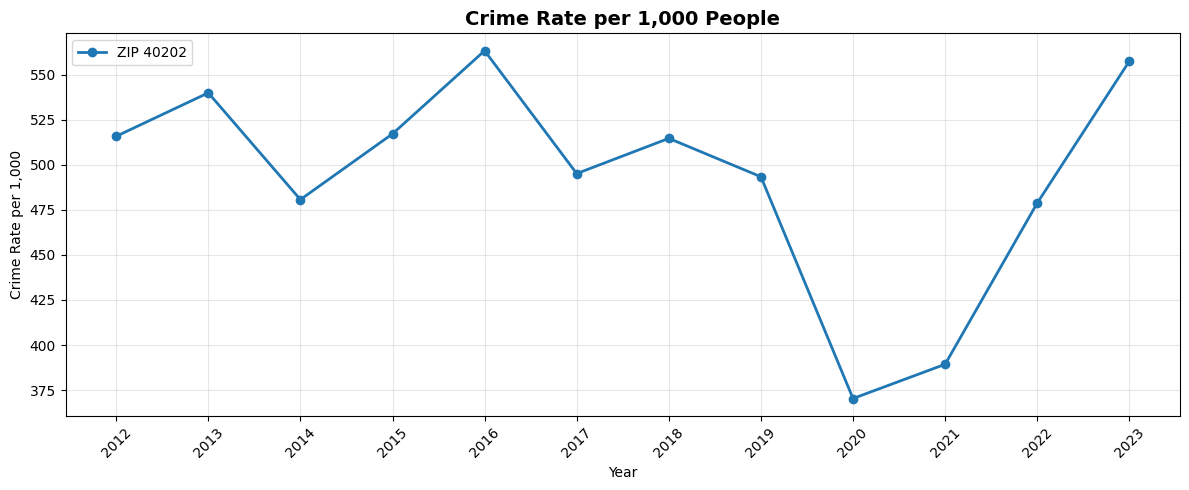

,zip_code,year,incident_count,total_population,crime_rate_per_1000
0,40202,2012,3316,6429.0,515.79
1,40202,2013,3478,6442.0,539.89
2,40202,2014,3109,6468.0,480.67
3,40202,2015,3290,6362.0,517.13
4,40202,2016,3611,6411.0,563.25
5,40202,2017,3380,6827.0,495.09
6,40202,2018,3693,7176.0,514.63
7,40202,2019,3549,7194.0,493.33
8,40202,2020,2887,7796.0,370.32
9,40202,2021,2898,7444.0,389.31


In [37]:
def crime_rate_calculator(zip_code, classification=None, plot=True, compare_zip=None):
    """
    Calculates crime rate per 1,000 people for a given ZIP code.
    Optionally filter by classification, plot results, and compare to another ZIP.
    
    Parameters:
        zip_code (str or int): A Louisville ZIP code e.g. '40202' or 40202
        classification (str, optional): A specific crime classification to filter by
            e.g. 'ASSAULT', 'THEFT/LARCENY'. If None, returns total crime rate.
        plot (bool): If True, displays a line chart. Default True.
        compare_zip (str or int, optional): A second ZIP code to compare against.
    
    Returns:
        DataFrame: Crime rate per 1,000 people by year
    
    Example usage:
        crime_rate_calculator('40202')
        crime_rate_calculator('40202', classification='ASSAULT')
        crime_rate_calculator('40202', compare_zip='40207')
        crime_rate_calculator('40202', classification='ASSAULT', compare_zip='40207')
    """
    
    def fetch_rates(zip_code, classification):
        """Inner function to fetch crime rates for a single ZIP."""
        zip_code = str(zip_code).strip()
        conn = sqlite3.connect('../data/lou_crime.db')
        
        if classification:
            df = pd.read_sql("""
                SELECT
                    cs.zip_code,
                    cs.year,
                    cs.offense_classification,
                    cs.incident_count,
                    zd.total_population,
                    ROUND(
                        cs.incident_count * 1000.0 / NULLIF(zd.total_population, 0), 2
                    ) AS crime_rate_per_1000
                FROM crime_summary cs
                JOIN zip_code_demographics zd
                    ON cs.zip_code = zd.zip_code
                    AND cs.year = zd.year
                WHERE cs.zip_code = ?
                AND cs.offense_classification = ?
                ORDER BY cs.year
            """, conn, params=[zip_code, classification.upper()])
        else:
            # No classification filter — aggregate all crime types into total rate
            df = pd.read_sql("""
                SELECT
                    cs.zip_code,
                    cs.year,
                    SUM(cs.incident_count)  AS incident_count,
                    zd.total_population,
                    ROUND(
                        SUM(cs.incident_count) * 1000.0 / NULLIF(zd.total_population, 0), 2
                    ) AS crime_rate_per_1000
                FROM crime_summary cs
                JOIN zip_code_demographics zd
                    ON cs.zip_code = zd.zip_code
                    AND cs.year = zd.year
                WHERE cs.zip_code = ?
                GROUP BY cs.zip_code, cs.year
                ORDER BY cs.year
            """, conn, params=[zip_code])
        
        conn.close()
        return df
    
    # --- Fetch data for primary ZIP ---
    zip_code = str(zip_code).strip()
    df = fetch_rates(zip_code, classification)
    
    if df.empty:
        print(f"No data found for ZIP code {zip_code}.")
        return None
    
    # --- Fetch data for comparison ZIP if provided ---
    df_compare = None
    if compare_zip:
        df_compare = fetch_rates(str(compare_zip).strip(), classification)
        if df_compare.empty:
            print(f"No data found for comparison ZIP {compare_zip}.")
            df_compare = None
    
    # --- Print summary ---
    print(f"\nCrime Rate Calculator — ZIP: {zip_code}")
    if classification:
        print(f"Classification filter: {classification.upper()}")
    print(f"Years covered: {df['year'].min()} - {df['year'].max()}")
    print(f"Average crime rate per 1,000: {df['crime_rate_per_1000'].mean():.2f}")
    print(f"Peak year: {df.loc[df['crime_rate_per_1000'].idxmax(), 'year']}")
    print(f"Peak rate: {df['crime_rate_per_1000'].max():.2f} per 1,000")
    
    if df_compare is not None:
        print(f"\nComparison ZIP: {compare_zip}")
        print(f"Average crime rate per 1,000: {df_compare['crime_rate_per_1000'].mean():.2f}")
        print(f"Peak year: {df_compare.loc[df_compare['crime_rate_per_1000'].idxmax(), 'year']}")
        print(f"Peak rate: {df_compare['crime_rate_per_1000'].max():.2f} per 1,000")
    
    # --- Plot ---
    if plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        
        # Plot primary ZIP
        ax.plot(
            df['year'],
            df['crime_rate_per_1000'],
            marker='o',
            linewidth=2,
            label=f'ZIP {zip_code}'
        )
        
        # Plot comparison ZIP if provided
        if df_compare is not None:
            ax.plot(
                df_compare['year'],
                df_compare['crime_rate_per_1000'],
                marker='o',
                linewidth=2,
                linestyle='--',
                label=f'ZIP {compare_zip}'
            )
        
        # Labels and formatting
        title = f"Crime Rate per 1,000 People"
        if classification:
            title += f" — {classification.upper()}"
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Crime Rate per 1,000')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xticks(df['year'].unique())
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    return df


# --- Test calls ---

# Total crime rate for one ZIP
crime_rate_calculator('40202')


Crime Rate Calculator — ZIP: 40211
Years covered: 2012 - 2023
Average crime rate per 1,000: 232.90
Peak year: 2016
Peak rate: 256.33 per 1,000

Comparison ZIP: 40207
Average crime rate per 1,000: 20.57
Peak year: 2017
Peak rate: 23.70 per 1,000


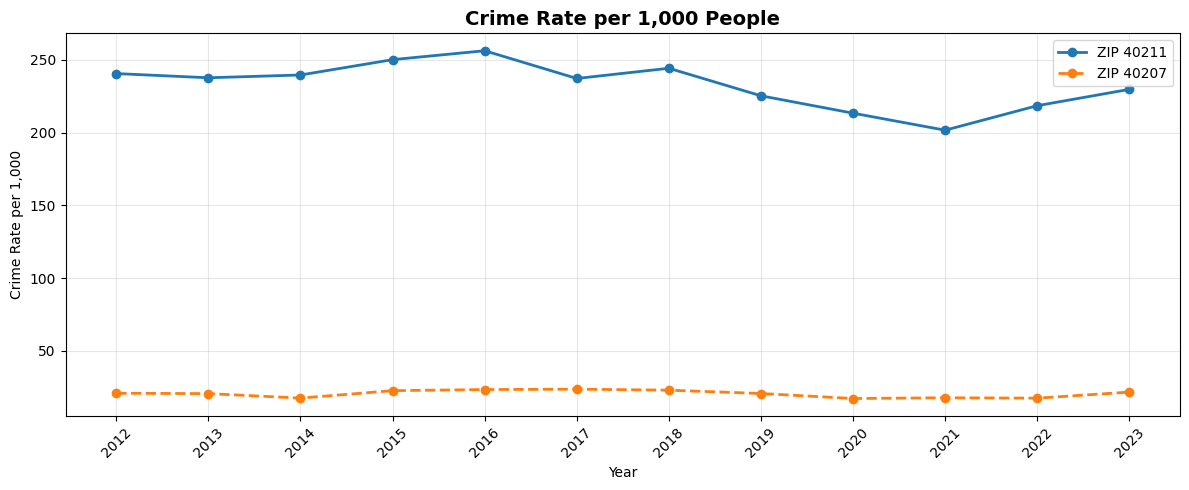

,zip_code,year,incident_count,total_population,crime_rate_per_1000
0,40211,2012,5479,22770.0,240.62
1,40211,2013,5301,22297.0,237.74
2,40211,2014,5661,23622.0,239.65
3,40211,2015,5863,23434.0,250.19
4,40211,2016,5851,22826.0,256.33
5,40211,2017,5476,23081.0,237.25
6,40211,2018,5671,23215.0,244.28
7,40211,2019,5083,22556.0,225.35
8,40211,2020,4805,22516.0,213.40
9,40211,2021,4471,22167.0,201.70


In [ ]:
# Compare two ZIPs — total crime rate
crime_rate_calculator('40211', compare_zip='40207')

# Visualizations

In [42]:
def plot_crime_by_zip(year=2022):
    """
    Bar chart of total crime incidents by ZIP code for a given year.
    ZIPs sorted from highest to lowest incident count.
    
    Parameters:
        year (int): Year to visualize. Default 2022.
    """
    conn = sqlite3.connect('../data/lou_crime.db')
    df = pd.read_sql("""
        SELECT
            cs.zip_code,
            SUM(cs.incident_count) AS total_incidents,
            zd.total_population,
            zd.poverty_rate
        FROM crime_summary cs
        JOIN zip_code_demographics zd
            ON cs.zip_code = zd.zip_code
            AND cs.year = zd.year
        WHERE cs.year = ?
        GROUP BY cs.zip_code
        ORDER BY total_incidents DESC
    """, conn, params=[year])
    conn.close()

    fig, ax = plt.subplots(figsize=(14, 6))

    # Color bars by incident count — darker red = higher crime
    colors = plt.cm.YlOrRd(
        [x / df['total_incidents'].max() for x in df['total_incidents']]
    )

    bars = ax.bar(df['zip_code'], df['total_incidents'], color=colors)

    # Add value labels on top of each bar
    for bar, val in zip(bars, df['total_incidents']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{int(val):,}',
            ha='center', va='bottom', fontsize=8
        )

    ax.set_title(f'Total Crime Incidents by ZIP Code — {year}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('ZIP Code')

### Top Zip codes crime rate - 2012 - 2023

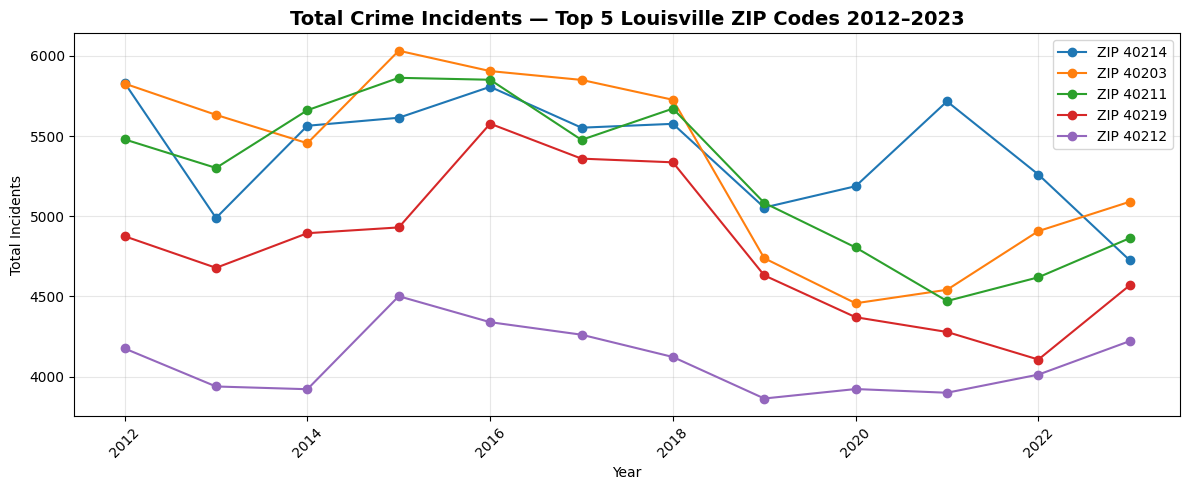

In [41]:
# Top 5 highest crime ZIPs — total incidents trend 2012-2023
top_zips = df_core.groupby('zip_code')['total_incidents'].mean().nlargest(5).index.tolist()
df_top = df_core[df_core['zip_code'].isin(top_zips)]

fig, ax = plt.subplots(figsize=(12, 5))
for zip_code in top_zips:
    data = df_top[df_top['zip_code'] == zip_code]
    ax.plot(data['year'], data['total_incidents'], marker='o', label=f'ZIP {zip_code}')

ax.set_title('Total Crime Incidents — Top 5 Louisville ZIP Codes 2012–2023',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Incidents')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Correlation Matrix

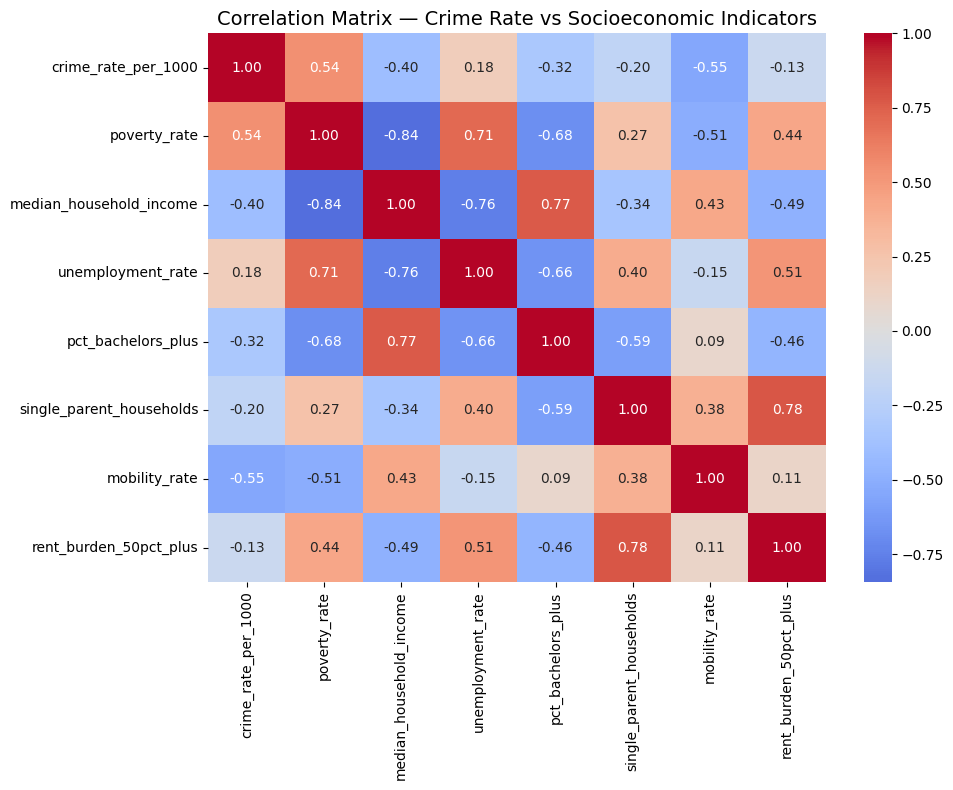

In [43]:
import seaborn as sns

corr_cols = [
    'crime_rate_per_1000', 'poverty_rate', 'median_household_income',
    'unemployment_rate', 'pct_bachelors_plus',
    'single_parent_households', 'mobility_rate', 'rent_burden_50pct_plus'
]

corr_matrix = df_core[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Correlation Matrix — Crime Rate vs Socioeconomic Indicators', fontsize=14)
plt.tight_layout()
plt.show()

### Regression Model

In [48]:
!pip install scikit-learn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Drop NaNs across all columns used in the model
df_reg = df_core.dropna(subset=[
    'crime_rate_per_1000',
    'poverty_rate',
    'unemployment_rate',
    'median_household_income',
    'pct_bachelors_plus',
    'single_parent_households'
])

print(f"Rows used in regression: {len(df_reg):,} of {len(df_core):,}")

X = df_reg[['poverty_rate', 'unemployment_rate',
            'median_household_income', 'pct_bachelors_plus',
            'single_parent_households']]
y = df_reg['crime_rate_per_1000']

model = LinearRegression()
model.fit(X, y)

print(f"\nR² Score: {r2_score(y, model.predict(X)):.3f}")
print("\nCoefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef:.3f}")
print(f"\nIntercept: {model.intercept_:.3f}")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Rows used in regression: 371 of 373

R² Score: 0.482

Coefficients:
  poverty_rate: 15.213
  unemployment_rate: -44.141
  median_household_income: 0.001
  pct_bachelors_plus: -9.666
  single_parent_households: -0.149

Intercept: 434.202
